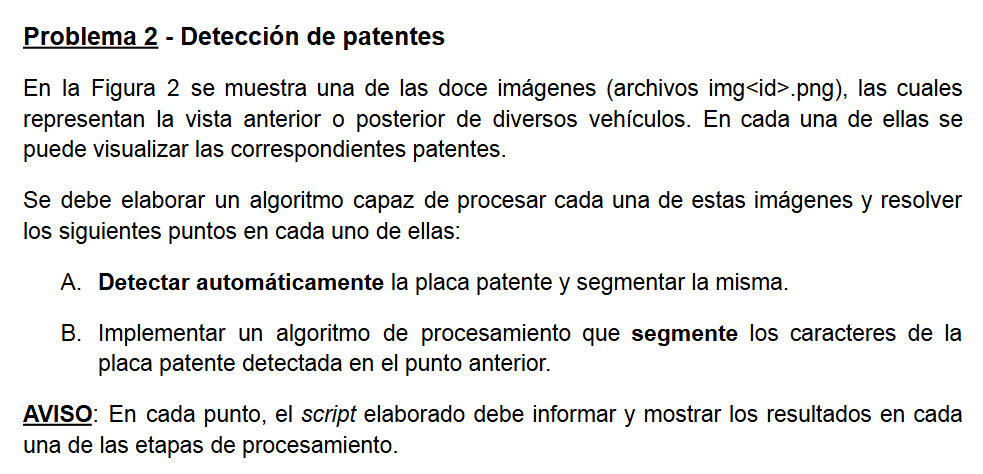

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

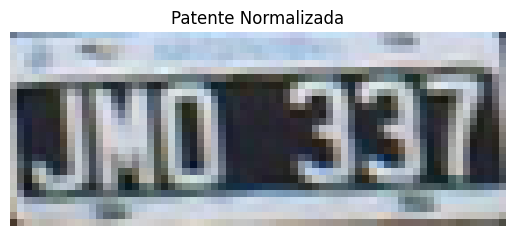

In [337]:
def detectar_patente(ruta_imagen):
    img = cv2.imread(ruta_imagen)
    

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    filtered = cv2.bilateralFilter(gray, 11, 19, 19)
    edged = cv2.Canny(filtered, 30, 190) 

    kernel = np.ones((3, 3), np.uint8)
    clausura = cv2.morphologyEx(edged, cv2.MORPH_CLOSE, kernel)

    contours, hierarchy = cv2.findContours(clausura.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    
    patente_contorno = None
    
    for c in contours:

        area = cv2.contourArea(c)
        perimeter = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.05* perimeter, True) 
        
        if area <3000 or area > 15000: 
            if len(approx) == 4:
                x, y, w, h = cv2.boundingRect(approx)
                aspect_ratio = w / float(h)
                
                if 1.5 <= aspect_ratio <= 3.0:
                    patente_contorno = approx
                    break 
    
    if patente_contorno is not None:
        
        def order_points(pts):
            rect = np.zeros((4, 2), dtype="float32")
            
            s = pts.sum(axis=1)
            rect[0] = pts[np.argmin(s)] 
            rect[2] = pts[np.argmax(s)] 

            diff = np.diff(pts, axis=1)
            rect[1] = pts[np.argmin(diff)] 
            rect[3] = pts[np.argmax(diff)] 

            return rect

        pts = patente_contorno.reshape(4, 2)
        rect = order_points(pts)
        (tl, tr, br, bl) = rect

        max_ancho = max(int(np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))), 
                                    int(np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))))
        
        max_alto = max(int(np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))), 
            int(np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))))

        dst = np.array([[0, 0],[max_ancho - 1, 0],[max_ancho - 1, max_alto - 1],[0, max_alto - 1]], dtype="float32")
        M = cv2.getPerspectiveTransform(rect, dst)
        patente_normalizada = cv2.warpPerspective(img, M, (max_ancho, max_alto))

        return patente_normalizada

    return None 



patente_img = detectar_patente('img/img08.png')
if patente_img is not None:

 plt.imshow(cv2.cvtColor(patente_img, cv2.COLOR_BGR2RGB))
 plt.axis('off')
 plt.title('Patente Normalizada')
 plt.show() 
else:
    print("No se detectó la patente.")


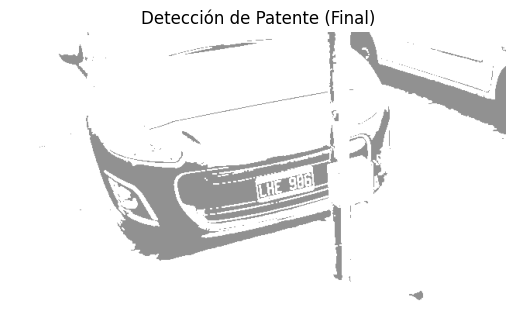

9

In [331]:

def detectar_patente_final(ruta_imagen):
    img = cv2.imread(ruta_imagen)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, patente_binaria = cv2.threshold(gray, 60, 110, cv2.THRESH_BINARY_INV) 
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    patente_solida = cv2.morphologyEx(patente_binaria, cv2.MORPH_CLOSE, kernel)
    invertida = cv2.bitwise_not(patente_solida)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(patente_solida, 8, cv2.CV_32S)

    objetos_stats = stats[1:]

    if len(objetos_stats) == 0:
        return (f"Cantidad total de caracteres: 0",
                f"Cantidad de espacios 'en blanco' (separaciones entre palabras): 0",
                f"Cantidad de palabras formadas: 0")


    MIN_AREA_FIJO = 50
    MIN_HEIGHT_FIJO = 32
    UMBRAL_ESPACIO_FIJO = 9


    componentes_validas = []

    for s in objetos_stats:
        x, y, w, h, area = s[0], s[1], s[2], s[3], s[4]

        if area >= MIN_AREA_FIJO and h >= MIN_HEIGHT_FIJO:

            componentes_validas.append({'x': x, 'x_fin': x + w})

    componentes_ordenadas = sorted(componentes_validas, key=lambda c: c['x'])
    cantidad_caracteres = len(componentes_ordenadas)


    contours, _ = cv2.findContours(patente_solida.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    
    mejor_patente = None
    min_distancia = float('inf')

    plt.imshow(cv2.cvtColor(invertida, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Detección de Patente (Final)")
    plt.show()

    return cantidad_caracteres

detectar_patente_final('img/img04.png')

In [ ]:
def detectar_patente(ruta_imagen):
    img = cv2.imread(ruta_imagen)
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    filtered = cv2.bilateralFilter(gray, 11, 17, 17)
    edged = cv2.Canny(filtered, 20, 200) 

    kernel = np.ones((5, 5), np.uint8)
   
    clausura = cv2.morphologyEx(edged, cv2.MORPH_CLOSE, kernel)

    contours, hierarchy = cv2.findContours(clausura.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    
    patente_contorno = None

    for c in contours:
        
        area = cv2.contourArea(c)

        if area < 1000 or area > 19000: 
             continue 
        
        perimeter = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.03 * perimeter, True) 
        
        if len(approx) == 4:
            x, y, w, h = cv2.boundingRect(approx)
            aspect_ratio = w / float(h)
            
            if 1.0 <= aspect_ratio <= 3.5:
                patente_contorno = approx
                break
            
    if patente_contorno is not None:
        img_final = img.copy()
        cv2.drawContours(img_final, [patente_contorno], -1, (0, 255, 0), 3)
        print("Resultado: Patente detectada por forma de contorno.")
        
        for point in patente_contorno:
             x, y = point[0]
             cv2.circle(img_final, (x, y), 8, (255, 0, 0), -1)
    else:
        img_final = img
        print("Fallo: No se encontró un contorno rectangular con el ratio esperado.")

    plt.imshow(img_final)
    plt.axis('off')
    plt.show()  

detectar_patente('img/img05.png')